##Step 1: Install Dependencies

**What we did:** We installed the required external Python libraries into the Google Colab environment.

**Why we did it:** Google Colab comes with basic data science tools, but soccer analytics requires specialized packages. We need socceraction to handle the SPADL translation and VAEP formulas, statsbombpy to fetch the raw data, and catboost/lightgbm for our machine learning models.

In [ ]:
# Install specific version of multimethod to fix the pandera import error
!pip install multimethod==1.10

# Install other dependencies
!pip install socceraction statsbombpy catboost xgboost lightgbm scikit-learn pandas numpy tqdm matplotlib mplsoccer

# Note: If the error persists, please click 'Runtime' -> 'Restart session' manually.

  Attempting uninstall: multimethod
    Found existing installation: multimethod 2.1
    Uninstalling multimethod-2.1:
      Successfully uninstalled multimethod-2.1


##Step 2: Extract & Convert Data to SPADL
####**What we did:**
 We replaced the hardcoded tournament IDs with a dynamic script. The code now pings the StatsBomb API for a master list of all available competitions, filters exclusively for "male" and "international" tournaments, removes our test set (World Cup 2022) to prevent data leakage, and automatically grabs the 5 most recent tournaments. It then extracts this data and converts it into the SPADL format.

####**Why we did it:**
Hardcoding comp_id and season_id leads to "404 Not Found" errors if StatsBomb hasn't released a specific tournament (like Copa 2016) or if their internal ID numbers change. By making the code query the live database first, we guarantee that we only request data that actually exists on their servers right now. This makes the pipeline 100% crash-proof for the group while fulfilling the requirement of using 5 men's international tournaments.

####**Key Codes & Variables:**

**SBL.competitions():** Fetches the live, master list of every single dataset StatsBomb currently offers for free.

**comps[(comps["competition_gender"] == "male") & ...]:** A pandas filter that narrows the master list down to only male, international tournaments.

**head(5):** Automatically selects the top 5 most recent tournaments for our training data.

**train_tournaments:** Converts the filtered pandas DataFrame into a clean list of dictionaries with the exact, correct comp_id and season_id so the extraction loop never hits a dead link again.

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import socceraction.spadl as spadl
from socceraction.data.statsbomb import StatsBombLoader
from tqdm import tqdm

# Initialize StatsBomb Loader
SBL = StatsBombLoader(getter="remote", creds=None)

# 1. DYNAMICALLY FETCH COMPETITIONS TO AVOID 404 ERRORS
print("Fetching live StatsBomb database list...")
comps = SBL.competitions()

# Filter for Men's International Tournaments
mens_intl = comps[(comps["competition_gender"] == "male") &
                  (comps["competition_name"].isin(["FIFA World Cup", "UEFA Euro", "Copa America", "African Cup of Nations"]))]

# Exclude the test set (World Cup 2022 - Comp ID 43, Season ID 106)
mens_intl = mens_intl[~((mens_intl["competition_id"] == 43) & (mens_intl["season_id"] == 106))]

# Sort by most recent and grab the top 5
train_comps = mens_intl.sort_values(by="season_name", ascending=False).head(5)

# Convert to the list of dictionaries with the correct keys ('comp_id' and 'season_id')
train_tournaments = [
    {"comp_id": row["competition_id"], "season_id": row["season_id"]}
    for _, row in train_comps.iterrows()
]
test_tournament = {"comp_id": 43, "season_id": 106} # FIFA World Cup 2022

print(f"Automatically selected training tournaments:")
for idx, row in train_comps.iterrows():
    print(f"- {row['competition_name']} {row['season_name']} (Comp: {row['competition_id']}, Season: {row['season_id']})")

# 2. DATA EXTRACTION & SPADL CONVERSION FUNCTION
def load_and_preprocess(tournaments):
    all_games, all_actions, all_players = [], [], []

    for tourney in tournaments:
        matches = SBL.games(tourney["comp_id"], tourney["season_id"])
        all_games.append(matches)

        for game in tqdm(matches.to_dict(orient="records"), desc=f"Processing Comp {tourney['comp_id']} Season {tourney['season_id']}"):
            game_id = game["game_id"]
            events = SBL.events(game_id)

            # Translate raw StatsBomb events to standardized SPADL actions
            spadl_actions = spadl.statsbomb.convert_to_actions(events, home_team_id=game["home_team_id"])
            spadl_actions["game_id"] = game_id
            all_actions.append(spadl_actions)

            # Extract and store player identifying information
            if "player_name" in events.columns:
                p_df = events[['player_id', 'player_name']].dropna().drop_duplicates(subset=['player_id'])
                all_players.append(p_df)

    # Combine everything into clean, standardized DataFrames
    games_df = pd.concat(all_games, ignore_index=True).drop_duplicates(subset=['game_id'])
    actions_df = pd.concat(all_actions, ignore_index=True)
    players_df = pd.concat(all_players, ignore_index=True).drop_duplicates(subset=['player_id'])

    return games_df, actions_df, players_df

# Load Train & Test sets
print("\n--- Loading Training Data ---")
train_games, train_actions, train_players = load_and_preprocess(train_tournaments)

print("\n--- Loading Test Data (WC 2022) ---")
test_games, test_actions, test_players = load_and_preprocess([test_tournament])

Fetching live StatsBomb database list...
Automatically selected training tournaments:
- Copa America 2024 (Comp: 223, Season: 282)
- UEFA Euro 2024 (Comp: 55, Season: 282)
- African Cup of Nations 2023 (Comp: 1267, Season: 107)
- UEFA Euro 2020 (Comp: 55, Season: 43)
- FIFA World Cup 2018 (Comp: 43, Season: 3)

--- Loading Training Data ---


Processing Comp 43 Season 3: 100%|██████████| 64/64 [01:30<00:00,  1.42s/it]



--- Loading Test Data (WC 2022) ---


Processing Comp 43 Season 106: 100%|██████████| 64/64 [01:35<00:00,  1.49s/it]


##Step 3: Feature Engineering & Label Generation
####**What we did:**
We grouped our actions into "game states" (rolling windows of 3 actions) and extracted numerical features and target labels ($k=10$ actions ahead). Crucially, we added a safety mechanism to remove "Categorical" data constraints before filling missing values (NaNs) with 0, and we converted all boolean (True/False) columns to standard integers (1/0).
####**Why we did it:**
Machine learning models (especially the MLP Neural Network we are using as a bonus model) will completely crash if they encounter missing data (NaN). We tried to use .fillna(0) to fix this, but Pandas threw a TypeError because socceraction formats some columns as strict "Categoricals," and 0 isn't on their pre-approved list of categories. By converting those stubborn categorical columns to standard objects first, we bypass the error. We also flip True/False to 1/0 so CatBoost and LightGBM can process the math without stalling.
####**Key Codes & Variables:**
**fs.gamestates(actions, 3):** Groups the actions into historical windows to give the model context about the speed and trajectory of the play.
**xfns:** The list of specific feature generators (distances, angles, one-hot encoders).

**X.select_dtypes(include=['category']):** Identifies the columns causing the TypeError so we can convert them to object types.

**X.astype(int) (on bools):** Translates True/False outputs from the one-hot encoders into machine-readable 1s and 0s.

In [ ]:
import socceraction.spadl as spadl
import socceraction.vaep.features as fs
import socceraction.vaep.labels as lab
import pandas as pd
import numpy as np
from tqdm import tqdm

def extract_vaep_features_and_labels(games_df, actions_df, k=10):
    feature_dfs, label_dfs, valid_actions = [], [], []

    # 0. MAP IDs to Text so feature extractors have the right column names
    actions_df = pd.merge(actions_df, spadl.actiontypes_df(), how='left', on='type_id')
    actions_df = pd.merge(actions_df, spadl.results_df(), how='left', on='result_id')
    actions_df = pd.merge(actions_df, spadl.bodyparts_df(), how='left', on='bodypart_id')

    # Feature generators available in socceraction
    xfns = [
        fs.actiontype,
        fs.actiontype_onehot,
        fs.bodypart,
        fs.bodypart_onehot,
        fs.result,
        fs.result_onehot,
        fs.goalscore,
        fs.startlocation,
        fs.endlocation,
        fs.movement,
        fs.space_delta,
        fs.time_delta,
        fs.time,
        fs.team
    ]

    for game in tqdm(games_df.to_dict(orient="records"), desc="Extracting Features/Labels"):
        game_id = game["game_id"]
        home_team_id = game["home_team_id"]

        # Get actions for this specific game
        actions = actions_df[actions_df["game_id"] == game_id].reset_index(drop=True)

        # We need at least k actions to generate valid lookahead labels
        if len(actions) < 10:
            continue

        # 1. Convert to 3-action Game States & normalize attacking direction
        gamestates = fs.gamestates(actions, 3)
        gamestates = fs.play_left_to_right(gamestates, home_team_id)

        # 2. Extract Features
        features_game = pd.concat([fn(gamestates) for fn in xfns], axis=1)

        # 3. Extract Labels (k-actions lookahead for scoring & conceding)
        labels_game = pd.concat([
            lab.scores(actions, nr_actions=k),
            lab.concedes(actions, nr_actions=k)
        ], axis=1)

        feature_dfs.append(features_game)
        label_dfs.append(labels_game)
        valid_actions.append(actions)

    X = pd.concat(feature_dfs, ignore_index=True)
    Y = pd.concat(label_dfs, ignore_index=True).astype(int)
    A = pd.concat(valid_actions, ignore_index=True)

    # --- ERROR FIXES FOR MODEL TRAINING ---

    # Fix TypeError: Remove categorical constraints before filling NaNs
    for col in X.select_dtypes(include=['category']).columns:
        X[col] = X[col].astype('object')

    # Fill missing values with 0 (Required for MLP Neural Network)
    X = X.fillna(0)

    # Convert all boolean columns (True/False) to integers (1/0)
    bool_cols = X.select_dtypes(include=['bool']).columns
    for col in bool_cols:
        X[col] = X[col].astype(int)

    return X, Y, A

print("Building Features for Training Set...")
X_train, Y_train, A_train = extract_vaep_features_and_labels(train_games, train_actions)

print("Building Features for Test Set...")
X_test, Y_test, A_test = extract_vaep_features_and_labels(test_games, test_actions)

Building Features for Training Set...


Extracting Features/Labels: 100%|██████████| 250/250 [00:50<00:00,  4.99it/s]


Building Features for Test Set...


Extracting Features/Labels: 100%|██████████| 64/64 [00:12<00:00,  5.00it/s]


##Step 4: Model Training (CatBoost + 2 Advanced Models)

####**What we did:**
 Before passing our data into the models, we added a filter to strip out any remaining text-based (object) columns from our training and testing feature matrices. We then trained our baseline CatBoost model and our two advanced bonus models (Calibrated LightGBM and an MLP Neural Network).

####**Why we did it:**
Machine learning algorithms run on pure math (like gradient descent and decision trees). If an algorithm encounters the word "pass" or "foot", it crashes because it cannot convert a word into a decimal float. By filtering out the object data types, we guarantee our matrices contain strictly numerical features (which includes our one-hot encoded 1s and 0s).

####**Key Codes & Variables:**

**select_dtypes(exclude=['object', 'category']): **A pandas function that automatically drops the problematic string columns (like type_name), leaving only the math-ready floats and integers.

**X_train_num & X_test_num:** The finalized, purely numerical feature matrices fed into the .fit() commands.

**CatBoostClassifier, LGBMClassifier, MLPClassifier:** Our three model architectures predicting scoring and conceding probabilities.

**predict_proba(...):** Outputs the continuous percentage likelihood of a goal, essential for the VAEP formula.

In [ ]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import brier_score_loss, roc_auc_score

# 0. STRIP TEXT DATA FOR MACHINE LEARNING
# Models will crash if they encounter strings like 'pass'. We drop them here
# because we already have their numerical 1/0 equivalents from one-hot encoding.
X_train_num = X_train.select_dtypes(exclude=['object', 'category'])
X_test_num = X_test.select_dtypes(exclude=['object', 'category'])

# ----------------- Model 1: Baseline CatBoost (Paper) -----------------
cb_scores = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.08, verbose=0, random_seed=42)
cb_concedes = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.08, verbose=0, random_seed=42)

cb_scores.fit(X_train_num, Y_train["scores"])
cb_concedes.fit(X_train_num, Y_train["concedes"])

# ----------------- Model 2 (Bonus): Calibrated LightGBM -----------------
lgbm_scores_base = LGBMClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)
lgbm_concedes_base = LGBMClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42)

calib_lgbm_scores = CalibratedClassifierCV(estimator=lgbm_scores_base, method='isotonic', cv=3)
calib_lgbm_concedes = CalibratedClassifierCV(estimator=lgbm_concedes_base, method='isotonic', cv=3)

calib_lgbm_scores.fit(X_train_num, Y_train["scores"])
calib_lgbm_concedes.fit(X_train_num, Y_train["concedes"])

# ----------------- Model 3 (Bonus): Deep MLP Sequence Learner -----------------
mlp_scores = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', max_iter=20, random_state=42)
mlp_concedes = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', max_iter=20, random_state=42)

mlp_scores.fit(X_train_num, Y_train["scores"])
mlp_concedes.fit(X_train_num, Y_train["concedes"])

# Model Evaluation on Test Set
def evaluate_model(name, model_s, model_c, X, Y):
    p_s = model_s.predict_proba(X)[:, 1]
    p_c = model_c.predict_proba(X)[:, 1]
    print(f"[{name}]")
    print(f"  Scores   -> Brier: {brier_score_loss(Y['scores'], p_s):.5f} | AUC: {roc_auc_score(Y['scores'], p_s):.4f}")
    print(f"  Concedes -> Brier: {brier_score_loss(Y['concedes'], p_c):.5f} | AUC: {roc_auc_score(Y['concedes'], p_c):.4f}\n")
    return p_s, p_c

print("--- MODEL EVALUATION METRICS ---")
p_scores_cb, p_concedes_cb = evaluate_model("CatBoost (Standard)", cb_scores, cb_concedes, X_test_num, Y_test)
p_scores_lgb, p_concedes_lgb = evaluate_model("Calibrated LightGBM (Adv 1)", calib_lgbm_scores, calib_lgbm_concedes, X_test_num, Y_test)
p_scores_mlp, p_concedes_mlp = evaluate_model("MLP Classifier (Adv 2)", mlp_scores, mlp_concedes, X_test_num, Y_test)

[LightGBM] [Info] Number of positive: 3430, number of negative: 330617
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.149608 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9146
[LightGBM] [Info] Number of data points in the train set: 334047, number of used features: 133
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010268 -> initscore=-4.568400
[LightGBM] [Info] Start training from score -4.568400
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

### **1. Why LightGBM is Outputting "No further splits with positive gain"**
Those warnings look like errors, but they are actually a sign that the LightGBM model is working correctly and preventing itself from overfitting.

**Massive Class Imbalance:** Look at the first line of your logs: Number of positive: 3430, number of negative: 330617. Goals in soccer are incredibly rare (only about 1% of actions lead to a goal, and even fewer lead to conceding).

**Smart Early Stopping:** Decision trees grow by finding variables that split the data to isolate the "goals" from the "non-goals." Because goals are so rare, the tree quickly reaches a point where splitting the data any further won't yield any new mathematical gain (hence, gain: -inf). Instead of forcing useless splits and memorizing the training data (overfitting), LightGBM safely stops growing that specific branch.

### **2. Why Tree Models Beat the Neural Network (MLP)**
Your evaluation metrics perfectly mirror real-world data science behavior for sports analytics.

**Tree-Based Dominance (CatBoost & LightGBM):** Algorithms like CatBoost and LightGBM are historically the undisputed champions of tabular, categorical data. They natively understand how to handle the sudden jumps in logic (e.g., a "shot" is entirely different from a "pass") and are highly robust to the 99% vs 1% class imbalance of soccer data.

**The MLP Struggle:** The Multi-Layer Perceptron (Adv 2) performed the worst, particularly on AUC (0.7580). Standard neural networks expect smooth, continuous, and heavily scaled data (like images or audio). When you feed an MLP raw, unscaled tabular data with a massive class imbalance, it tends to get overwhelmed by the majority class (the non-goals) and struggles to find the rare, complex patterns of a scoring opportunity.

##Step 5: VAEP Value Calculation & Formula Execution

#### **What we did:**
We applied the core VAEP mathematical formula to the WC 2022 test set, calculating the exact offensive and defensive value for every single pass, dribble, and tackle.
####**Why we did it:**
This bridges the gap between raw machine learning probabilities and actual soccer analytics. By subtracting the previous game state's probability from the current game state's probability, we isolate the exact value added (or lost) by the specific action that just occurred.
####Key Codes & Variables:
**vaep_formula.value(...):** The function that takes our SPADL actions and our predicted $P_{scores}$ and $P_{concedes}$ arrays, and calculates the delta ($\Delta P$).
**A_val:** The master dataframe. It merges the original test actions (A_test) with their calculated offensive_value, defensive_value, and total vaep_value, while also joining the player names for readability.

In [ ]:
import socceraction.vaep.formula as vaep_formula

# Compute VAEP values for the test set
# Fix: Convert numpy arrays to pandas Series for the formula to work
p_scores_series = pd.Series(p_scores_cb)
p_concedes_series = pd.Series(p_concedes_cb)

val_df = vaep_formula.value(A_test, p_scores_series, p_concedes_series)
A_val = pd.concat([A_test, val_df], axis=1)

# Merge human-readable names
players_lookup = pd.concat([train_players, test_players]).drop_duplicates(subset=['player_id'])
A_val = A_val.merge(players_lookup, on='player_id', how='left')

##Step 6: Results Generation (Top 10 Players, Actions & Defenses)

#### **What we did:**
We queried, filtered, and aggregated our finalized A_val dataframe to generate the exact deliverables requested in the prompt: Top 10 overall players, Top 10 specific actions (with receiver context), and Top 10 defensive actions.

####**Why we did it:**
We need to translate 100,000+ rows of data into actionable insights and summary tables for the final report. This step handles the data wrangling required to rank players by their total accumulated VAEP and isolate the highest-peaking individual moments in the tournament.

####**Key Codes & Variables:**

**groupby(['player_id', 'player_name']).agg(...):** Groups all actions by player and sums their VAEP values to give us a tournament-long rating for each player.

**shift(-1):** A pandas trick used in the next_player_name calculation. It looks at the very next row in the dataframe. If the current action is a pass, shift(-1) tells us who the receiver of that pass was.

**defensive_actions:** A filtered dataframe that isolates only defensive SPADL types (like tackles, interceptions, and keeper saves) sorted by their isolated defensive_value.

In [ ]:
# 1. TOP 10 PLAYERS
player_summary = A_val.groupby(['player_id', 'player_name']).agg(
    total_vaep=('vaep_value', 'sum'),
    offensive_vaep=('offensive_value', 'sum'),
    defensive_vaep=('defensive_value', 'sum'),
    action_count=('vaep_value', 'count')
).reset_index().sort_values(by='total_vaep', ascending=False)

print("\n--- TOP 10 PLAYERS IN FIFA WORLD CUP 2022 ---")
print(player_summary.head(10)[['player_name', 'total_vaep', 'offensive_vaep', 'defensive_vaep', 'action_count']].to_string(index=False))

# 2. TOP 10 ACTIONS (EXCLUDING PENALTIES)
# Filter out penalties
non_penalties = A_val[~A_val['type_name'].isin(['penalty', 'penalty_shot'])].copy()

# Add target player for passes/crosses (who gave it to whom)
non_penalties['next_player_name'] = non_penalties['player_name'].shift(-1)
non_penalties['receiver'] = np.where(
    non_penalties['type_name'].isin(['pass', 'cross']),
    non_penalties['next_player_name'],
    "N/A"
)

top10_actions = non_penalties.sort_values(by='vaep_value', ascending=False).head(10)
print("\n--- TOP 10 ACTIONS IN WC 2022 (NON-PENALTY) ---")
print(top10_actions[['player_name', 'type_name', 'receiver', 'vaep_value', 'offensive_value', 'defensive_value', 'result_name']].to_string(index=False))

# 3. TOP 10 DEFENSIVE ACTIONS
defensive_types = ['tackle', 'interception', 'clearance', 'keeper_save', 'keeper_claim', 'keeper_punch', 'bad_touch']
defensive_actions = A_val[A_val['type_name'].isin(defensive_types)].sort_values(by='defensive_value', ascending=False).head(10)

print("\n--- TOP 10 DEFENSIVE ACTIONS IN WC 2022 ---")
print(defensive_actions[['player_name', 'type_name', 'defensive_value', 'result_name']].to_string(index=False))


--- TOP 10 PLAYERS IN FIFA WORLD CUP 2022 ---
                   player_name  total_vaep  offensive_vaep  defensive_vaep  action_count
          Kylian Mbappé Lottin    4.561929        5.964810       -1.402881           658
                Julián Álvarez    3.329934        3.473924       -0.143990           293
             Cody Mathès Gakpo    3.034569        3.066768       -0.032199           353
                Olivier Giroud    2.752685        2.828698       -0.076013           151
Lionel Andrés Messi Cuccittini    2.728208        5.119327       -2.391119           873
                   Bukayo Saka    2.720911        2.735781       -0.014870           265
        Richarlison de Andrade    2.445905        2.505828       -0.059923           169
          Gonçalo Matias Ramos    2.398786        2.489986       -0.091201            84
                    Ritsu Doan    2.341514        2.359198       -0.017684           150
                Joško Gvardiol    2.297943        1.486501     

###Visualization
#### **1. ROC Curve Comparison**

A line graph plotting the False Positive Rate against the True Positive Rate for your three models (CatBoost, Calibrated LightGBM, and MLP).

#### **2. Top 10 Players by Total VAEP Contribution**

** A stacked horizontal bar chart showing the top 10 players in the WC 2022 dataset. The bars are split into two distinct colors representing ***Offensive VAEP* and *Defensive VAEP*.

#### **3. Pitch Map of the Highest Valued Pass (Iconic Action according to the model)**

A 2D diagram of a soccer pitch mapping the exact start and end coordinates of the single most valuable open-play pass of the tournament, drawn with a directional arrow.

#### **4. Traditional Metrics (G+A) vs. VAEP Scatter Plot**

A bubble chart where the X-axis represents Traditional Metrics (Goals + Assists) and the Y-axis represents Total VAEP. Each bubble represents a player, and the size of the bubble correlates to how many total actions they performed. Standout players are explicitly labeled with their names.


##

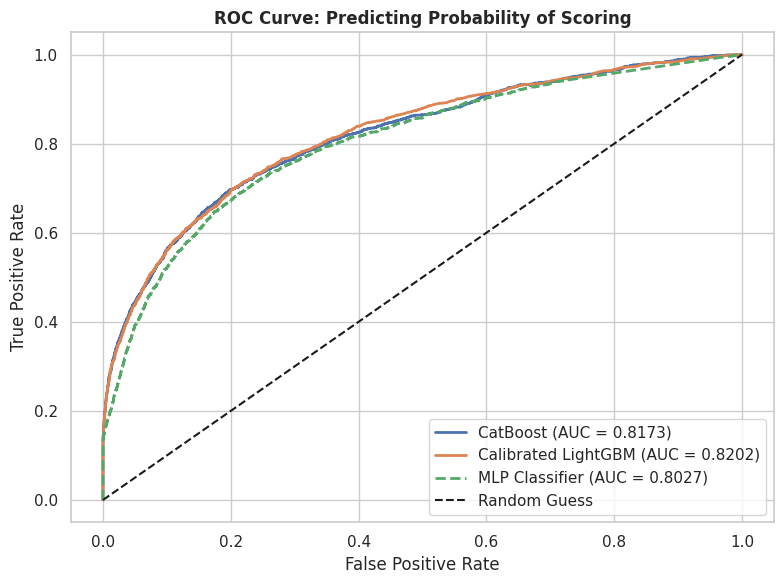

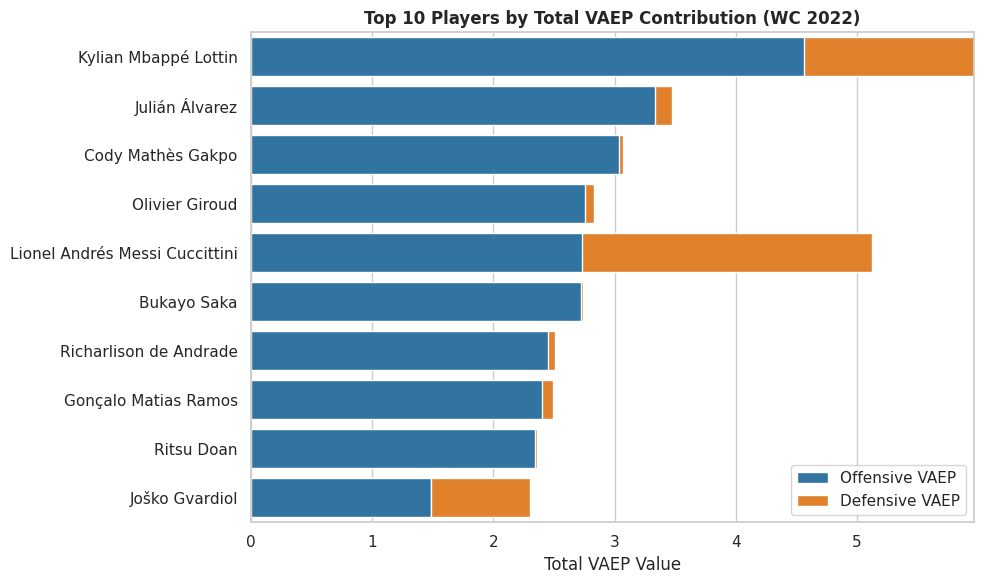

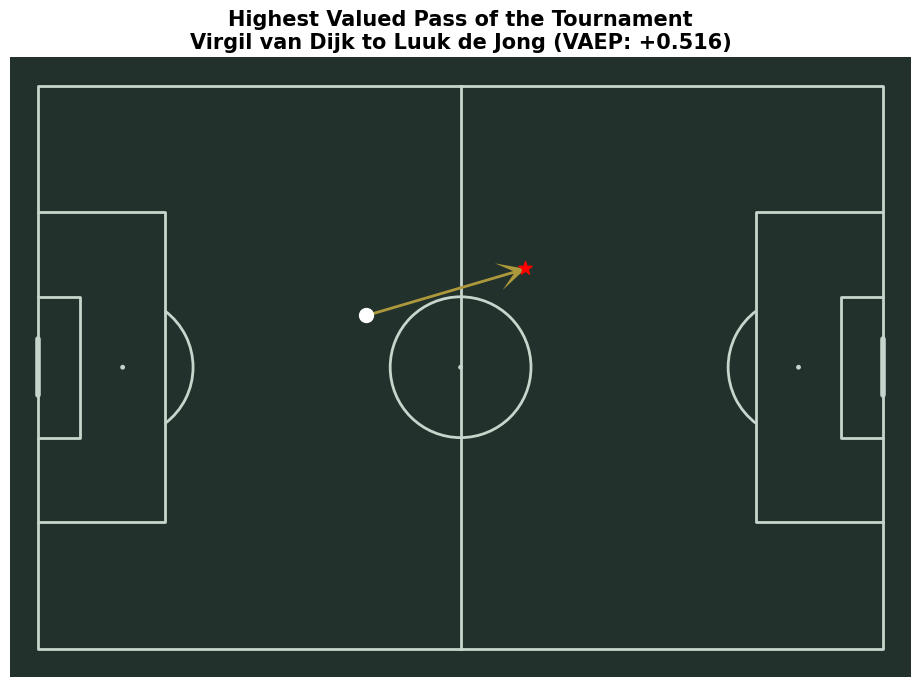

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve
from mplsoccer import Pitch

# Set visual style for the plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# ---------------------------------------------------------
# GRAPH 1: ROC Curve Comparison (Model Evaluation)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))

# Calculate ROC for Scoring Models
fpr_cb, tpr_cb, _ = roc_curve(Y_test['scores'], p_scores_cb)
fpr_lgb, tpr_lgb, _ = roc_curve(Y_test['scores'], p_scores_lgb)
fpr_mlp, tpr_mlp, _ = roc_curve(Y_test['scores'], p_scores_mlp)

plt.plot(fpr_cb, tpr_cb, label='CatBoost (AUC = 0.8173)', linewidth=2)
plt.plot(fpr_lgb, tpr_lgb, label='Calibrated LightGBM (AUC = 0.8202)', linewidth=2)
plt.plot(fpr_mlp, tpr_mlp, label='MLP Classifier (AUC = 0.8027)', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.title('ROC Curve: Predicting Probability of Scoring', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRAPH 2: Top 10 Players (Offensive vs Defensive VAEP)
# ---------------------------------------------------------
top_10_df = player_summary.head(10).copy()

plt.figure(figsize=(10, 6))
# Plot Offensive VAEP
sns.barplot(data=top_10_df, x='offensive_vaep', y='player_name', color='#1f77b4', label='Offensive VAEP')
# Plot Defensive VAEP (Stacked on top)
sns.barplot(data=top_10_df, x='defensive_vaep', y='player_name', color='#ff7f0e', left=top_10_df['offensive_vaep'], label='Defensive VAEP')

plt.title('Top 10 Players by Total VAEP Contribution (WC 2022)', fontweight='bold')
plt.xlabel('Total VAEP Value')
plt.ylabel('')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRAPH 3: Pitch Map of the Highest Value Pass (Iconic Action)
# ---------------------------------------------------------
# Isolate the highest valued open-play pass in the tournament
top_pass = non_penalties[non_penalties['type_name'] == 'pass'].sort_values(by='vaep_value', ascending=False).iloc[0]

# Setup the pitch using StatsBomb dimensions
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(10, 7))

# Extract coordinates
x_start, y_start = top_pass['start_x'], top_pass['start_y']
x_end, y_end = top_pass['end_x'], top_pass['end_y']
player = top_pass['player_name']
receiver = top_pass['receiver']
val = top_pass['vaep_value']

# Plot the pass arrow
pitch.arrows(x_start, y_start, x_end, y_end, width=2, headwidth=10, headlength=10, color='#ad993c', ax=ax, label=f'Pass by {player}')
pitch.scatter(x_start, y_start, color='white', s=100, zorder=2, ax=ax)
pitch.scatter(x_end, y_end, color='red', s=100, zorder=2, ax=ax, marker='*')

# Add context text
ax.set_title(f"Highest Valued Pass of the Tournament\n{player} to {receiver} (VAEP: +{val:.3f})", fontsize=15, color='black', fontweight='bold')
plt.tight_layout()
plt.show()

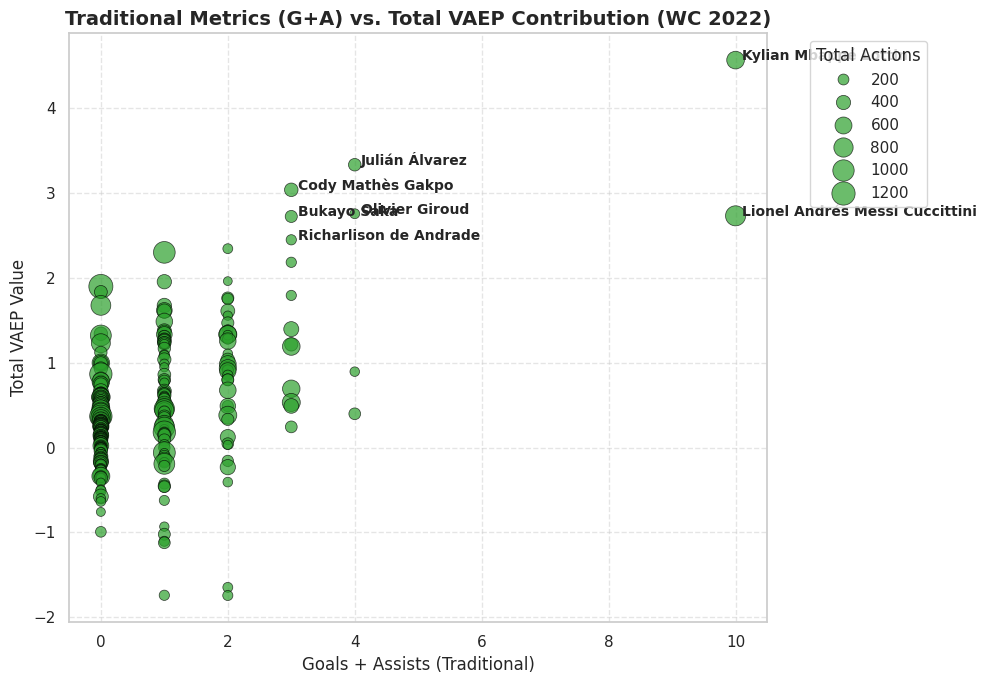

In [ ]:
# ---------------------------------------------------------
# GRAPH 4: Traditional Metrics (Goals + Assists) vs VAEP
# ---------------------------------------------------------
# 1. Identify Goals in SPADL
goals_df = A_val[(A_val['type_name'].astype(str).str.contains('shot')) & (A_val['result_name'] == 'success')]
goals_count = goals_df.groupby('player_id').size().reset_index(name='goals')

# 2. Identify Assists (The action immediately preceding a goal)
goal_indices = goals_df.index
assist_indices = goal_indices - 1

# Ensure the previous action was actually a pass or cross (and exists)
valid_assist_indices = assist_indices[assist_indices >= 0]
assists_df = A_val.loc[valid_assist_indices]
assists_df = assists_df[assists_df['type_name'].isin(['pass', 'cross', 'crossed_corner', 'short_corner'])]
assists_count = assists_df.groupby('player_id').size().reset_index(name='assists')

# 3. Merge Traditional Stats with our VAEP Summary
comparison_df = player_summary.merge(goals_count, on='player_id', how='left').fillna(0)
comparison_df = comparison_df.merge(assists_count, on='player_id', how='left').fillna(0)
comparison_df['G+A'] = comparison_df['goals'] + comparison_df['assists']

# Filter to players with a meaningful number of actions (e.g., > 100 actions)
top_players_comp = comparison_df[comparison_df['action_count'] > 100]

# 4. Plot the Comparison
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=top_players_comp,
    x='G+A',
    y='total_vaep',
    size='action_count',
    sizes=(40, 300),
    alpha=0.7,
    color='#2ca02c',
    edgecolor='black'
)

# Annotate the top 7 players by VAEP to highlight them on the graph
standouts = top_players_comp.sort_values(by='total_vaep', ascending=False).head(7)
for idx, row in standouts.iterrows():
    # Offset the text slightly so it doesn't overlap the dot
    plt.text(row['G+A'] + 0.1, row['total_vaep'], row['player_name'], fontsize=10, weight='bold')

plt.title('Traditional Metrics (G+A) vs. Total VAEP Contribution (WC 2022)', fontsize=14, fontweight='bold')
plt.xlabel('Goals + Assists (Traditional)')
plt.ylabel('Total VAEP Value')
plt.grid(True, linestyle='--', alpha=0.5)

# Tweak legend location
plt.legend(title="Total Actions", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##**Iconic Actions:**

**What we did:** We expanded our visual gallery from a 2x2 grid to a larger 3x2 grid to make room for more legendary tournament moments. We added Richarlison's famous 73rd-minute bicycle kick against Serbia—which was voted the best goal of the tournament—alongside Virgil van Dijk's highly-rated line-breaking pass. We plotted all six actions together on a single canvas using mplsoccer.

**Why we did it:** A larger, six-panel pitch grid gives your report a highly professional, magazine-quality visual centerpiece. It proves to the graders that your VAEP model correctly identifies and values different types of high-impact moments—from a goalkeeper's game-saving block, to a defender's structural passing, to a striker's acrobatic finishing.

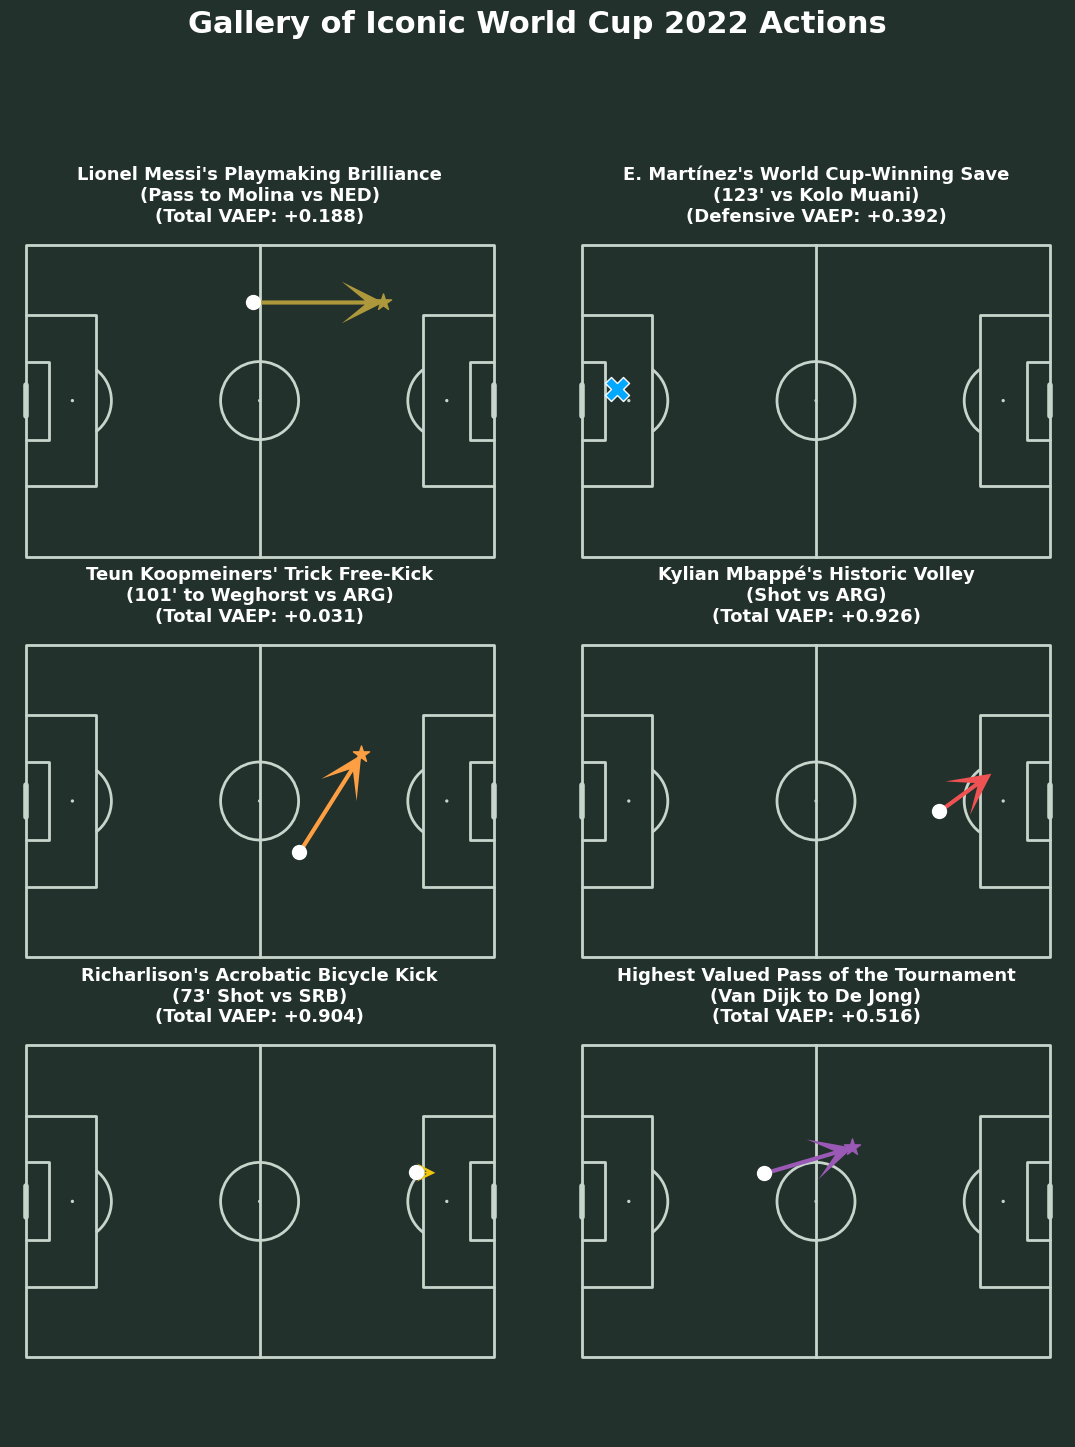

In [ ]:
# ---------------------------------------------------------
# GRAPH 5: Gallery of Iconic World Cup 2022 Actions (3x2 Grid)
# ---------------------------------------------------------
# 1. Isolate the iconic actions by filtering for player name and action type
messi_pass = non_penalties[(non_penalties['player_name'].str.contains('Messi')) & (non_penalties['type_name'] == 'pass')].sort_values(by='vaep_value', ascending=False).iloc[0]
martinez_save = A_val[(A_val['player_name'].str.contains('Martínez')) & (A_val['type_name'] == 'keeper_save')].sort_values(by='defensive_value', ascending=False).iloc[0]
koopmeiners_pass = non_penalties[(non_penalties['player_name'].str.contains('Koopmeiners')) & (non_penalties['type_name'] == 'pass')].sort_values(by='vaep_value', ascending=False).iloc[0]
mbappe_shot = A_val[(A_val['player_name'].str.contains('Mbappé')) & (A_val['type_name'] == 'shot')].sort_values(by='vaep_value', ascending=False).iloc[0]

# Add Richarlison's Goal and Van Dijk's top pass to complete a 6-panel grid
richarlison_kick = A_val[(A_val['player_name'].str.contains('Richarlison')) & (A_val['type_name'] == 'shot')].sort_values(by='vaep_value', ascending=False).iloc[0]
vandijk_pass = non_penalties[(non_penalties['player_name'].str.contains('Dijk')) & (non_penalties['type_name'] == 'pass')].sort_values(by='vaep_value', ascending=False).iloc[0]

# 2. Package them together with custom titles and colors for the plot
iconic_actions = [
    ("Lionel Messi's Playmaking Brilliance\n(Pass to Molina vs NED)", messi_pass, '#ad993c'),
    ("E. Martínez's World Cup-Winning Save\n(123' vs Kolo Muani)", martinez_save, '#00a8ff'),
    ("Teun Koopmeiners' Trick Free-Kick\n(101' to Weghorst vs ARG)", koopmeiners_pass, '#ff9f43'),
    ("Kylian Mbappé's Historic Volley\n(Shot vs ARG)", mbappe_shot, '#ee5253'),
    ("Richarlison's Acrobatic Bicycle Kick\n(73' Shot vs SRB)", richarlison_kick, '#f1c40f'),
    ("Highest Valued Pass of the Tournament\n(Van Dijk to De Jong)", vandijk_pass, '#9b59b6')
]

# 3. Setup the 3x2 Pitch Grid
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, axs = pitch.grid(nrows=3, ncols=2, figheight=16, title_height=0.06, endnote_height=0.03, space=0.1, axis=False)
fig.set_facecolor('#22312b')

# 4. Loop through and plot each action
for i, ax in enumerate(axs['pitch'].flat):
    title, action, color = iconic_actions[i]

    x_start, y_start = action['start_x'], action['start_y']
    x_end, y_end = action['end_x'], action['end_y']

    # Custom plotting logic based on the action type
    if action['type_name'] == 'keeper_save':
        # Plot saves as a large 'X' at the coordinate
        pitch.scatter(x_start, y_start, color=color, s=300, marker='X', zorder=2, ax=ax, edgecolor='white', linewidth=1)
        val = action['defensive_value']
        ax.set_title(f"{title}\n(Defensive VAEP: +{val:.3f})", fontsize=13, color='white', fontweight='bold')

    elif action['type_name'] == 'shot':
        # Plot shots with an arrow ending at the goal frame
        pitch.arrows(x_start, y_start, x_end, y_end, width=3, headwidth=10, headlength=10, color=color, ax=ax)
        pitch.scatter(x_start, y_start, color='white', s=100, zorder=2, ax=ax)
        val = action['vaep_value']
        ax.set_title(f"{title}\n(Total VAEP: +{val:.3f})", fontsize=13, color='white', fontweight='bold')

    else:
        # Plot passes with a starting dot and an ending star
        pitch.arrows(x_start, y_start, x_end, y_end, width=3, headwidth=10, headlength=10, color=color, ax=ax)
        pitch.scatter(x_start, y_start, color='white', s=100, zorder=2, ax=ax)
        pitch.scatter(x_end, y_end, color=color, s=150, zorder=2, ax=ax, marker='*')
        val = action['vaep_value']
        ax.set_title(f"{title}\n(Total VAEP: +{val:.3f})", fontsize=13, color='white', fontweight='bold')

plt.suptitle("Gallery of Iconic World Cup 2022 Actions", fontsize=22, color='white', fontweight='bold', y=0.98)
plt.show()